In [7]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from scipy.optimize import curve_fit

In [8]:
dataF = np.load('dataF.npy')
dataN = np.load('dataN.npy')
dataO = np.load('dataO.npy')
dataS = np.load('dataS.npy')
dataZ = np.load('dataZ.npy')

folders = [dataF, dataN, dataO, dataS, dataZ]
filenames = ['F', 'N', 'O', 'S', 'Z']

data = dataF[0]

scales = 9
time = np.linspace(0, 23.6, len(dataF[0]))
epochs = np.logspace(
    np.log10(4),
    np.log10(4096/4),
    scales)

x_extrapolate = np.linspace(4, 4096/4, 100)

print(epochs)

[   4.    8.   16.   32.   64.  128.  256.  512. 1024.]


In [ ]:
def prepros(tseries):
    mean = np.mean(tseries)
    mean_centered = tseries - mean
    prepros = np.cumsum(mean_centered)
    return prepros

def linear(x, m, b):
    return m*x + b

def sigmoid1(x, L ,x0, k, b):
    return L / (1 + np.exp(-k*(x-x0))) + b

def gaussian(x, amplitude, mean, sigma):
    return amplitude * np.exp(-((x - mean) ** 2) / (2 * sigma ** 2))

def fitting(segment_y, segment_x):
    popt, pcov = curve_fit(linear, segment_x, segment_y)
    m, b = popt
    return m, b

def RMS_i(f1,f2,n):
    rms_i = np.sqrt( (1/n) * np.sum((f1 - f2)**2) )
    return rms_i

def RMS(rms_i_list):
    F_n = np.sqrt( (1/len(rms_i_list)) * np.sum(np.array(rms_i_list)**2) )
    return F_n

def DFA(prepros):
    RMS_list = []
    for i in epochs:
        boundaries = np.arange(0,4097,i).astype(int)
        rms_i_list = []

        # Epoch processing
        for j in range(len(boundaries)-1):
            segment_x = [k for k in range(int(boundaries[j]), int(boundaries[j+1]))]
            segment_y = prepros[boundaries[j]:boundaries[j+1]]

            # Fitting
            m, b = fitting(segment_y, segment_x)

            # RMS Computation 
            rms_i = RMS_i(segment_y, linear(np.array(segment_x), m, b), i)
            rms_i_list.append(rms_i)
        
        F_n = RMS(rms_i_list)
        RMS_list.append(F_n)
    return RMS_list 

In [ ]:
# DATA GENERATION
for folder in range(len(folders)):
    DFA_results = []
    DFA_Hurst = []
    DFA_linfit = []

    for file in folders[folder]:
        data = file
        processed = prepros(data)
        DFA_result = DFA(processed)
        DFA_results.append(DFA_result)

        m1 , b1 = fitting(np.log(DFA_result), np.log(epochs))
        DFA_linfit.append([m1, b1])
        DFA_Hurst.append(m1)    

    np.array(DFA_results).astype(float)
    np.array(DFA_Hurst)
    np.array(DFA_linfit).astype(float)
    np.save(f'DFA_{filenames[folder]}_results.npy', np.array(DFA_results))
    np.save(f'DFA_{filenames[folder]}_Hurst.npy', np.array(DFA_Hurst))
    np.save(f'DFA_{filenames[folder]}_sigfit.npy', np.array(DFA_linfit))


# Plotting
DFA datapoints = "DFA_X_results.npy" 
Hurst Exponents = "DFA_X_Hurst.npy"

x-axis for epochs = "epochs"

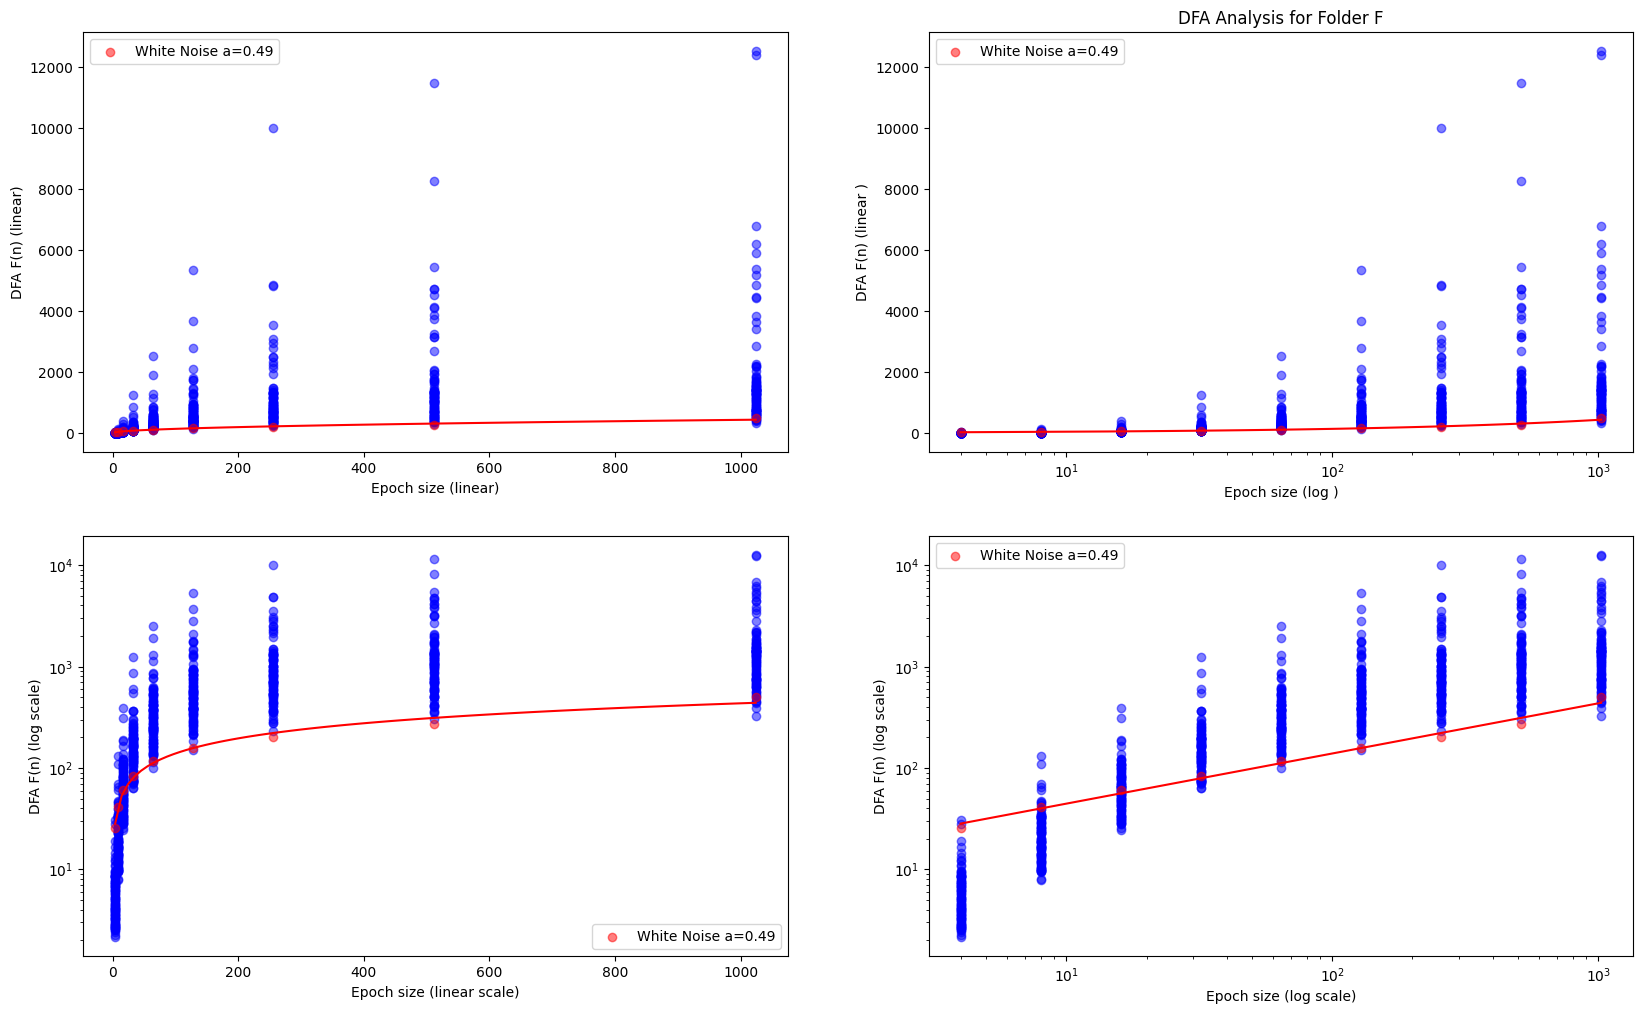

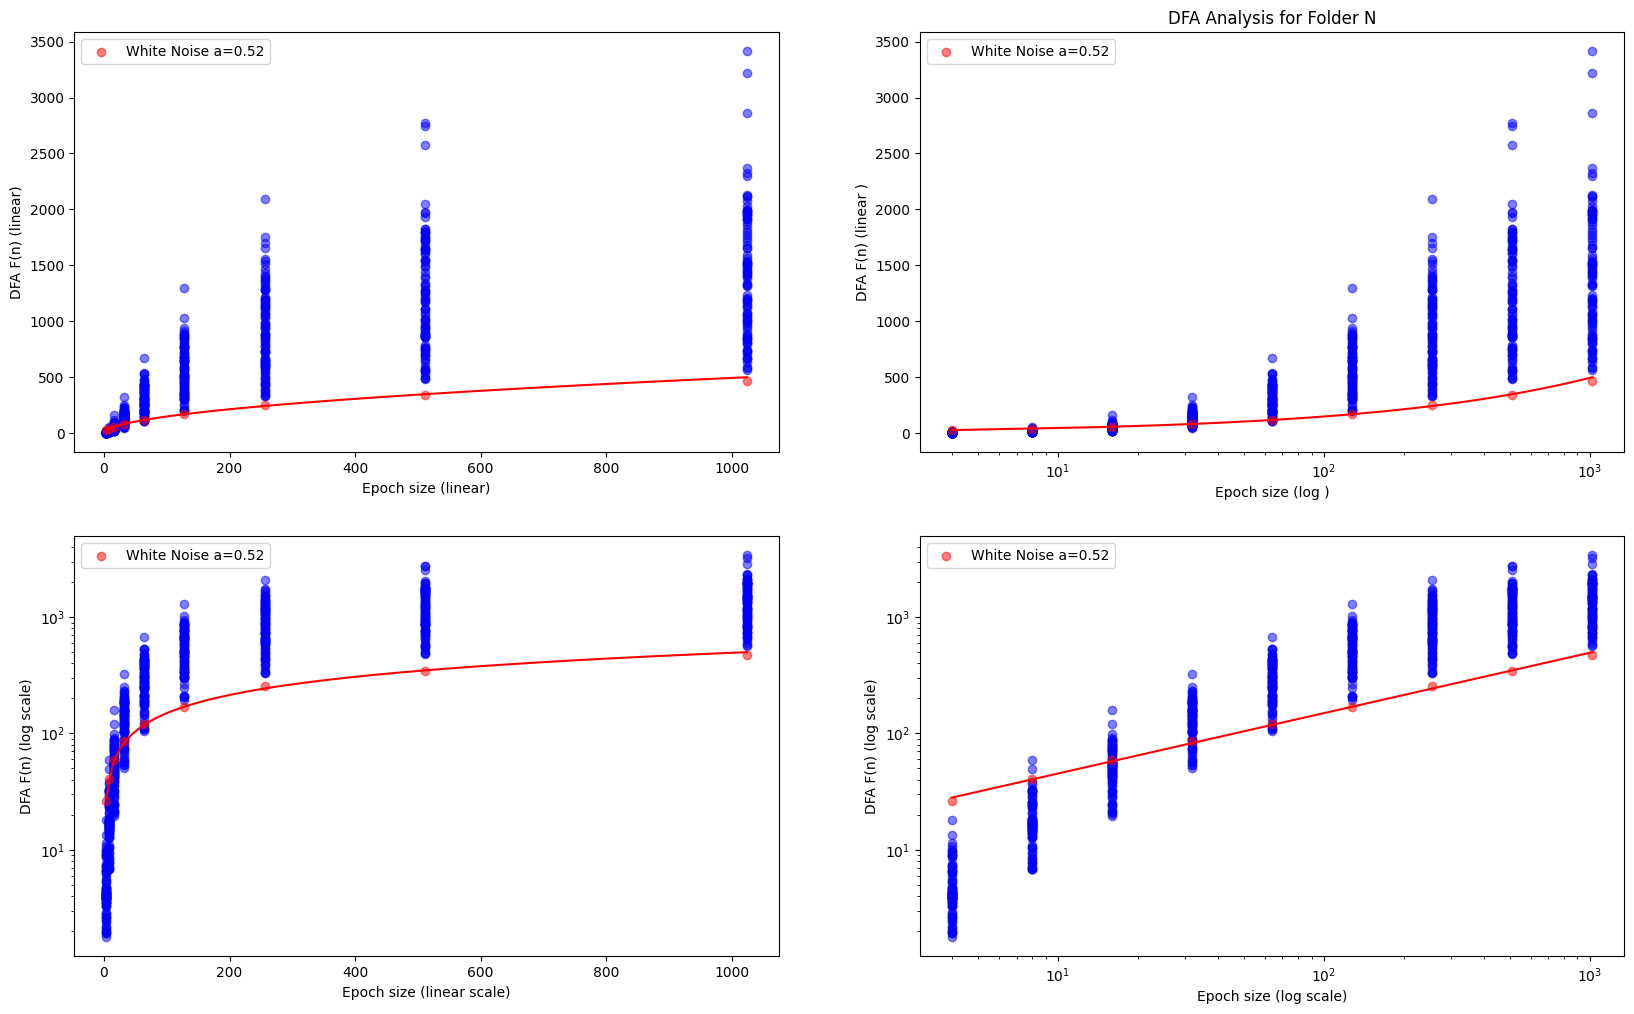

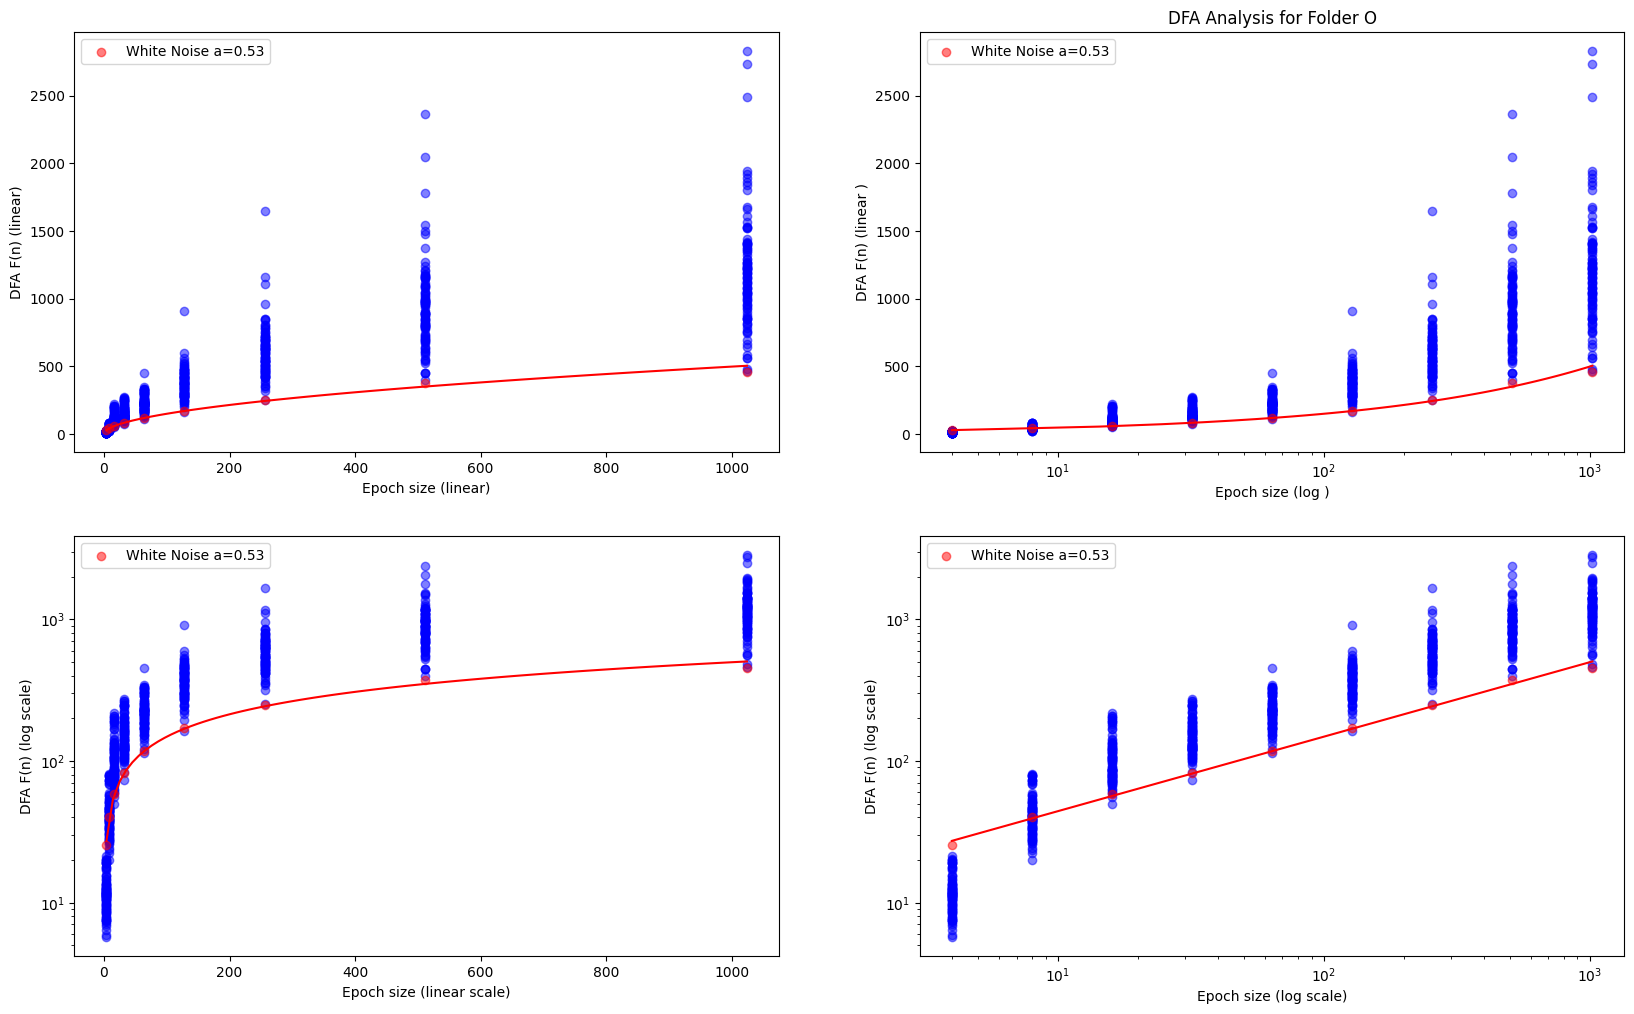

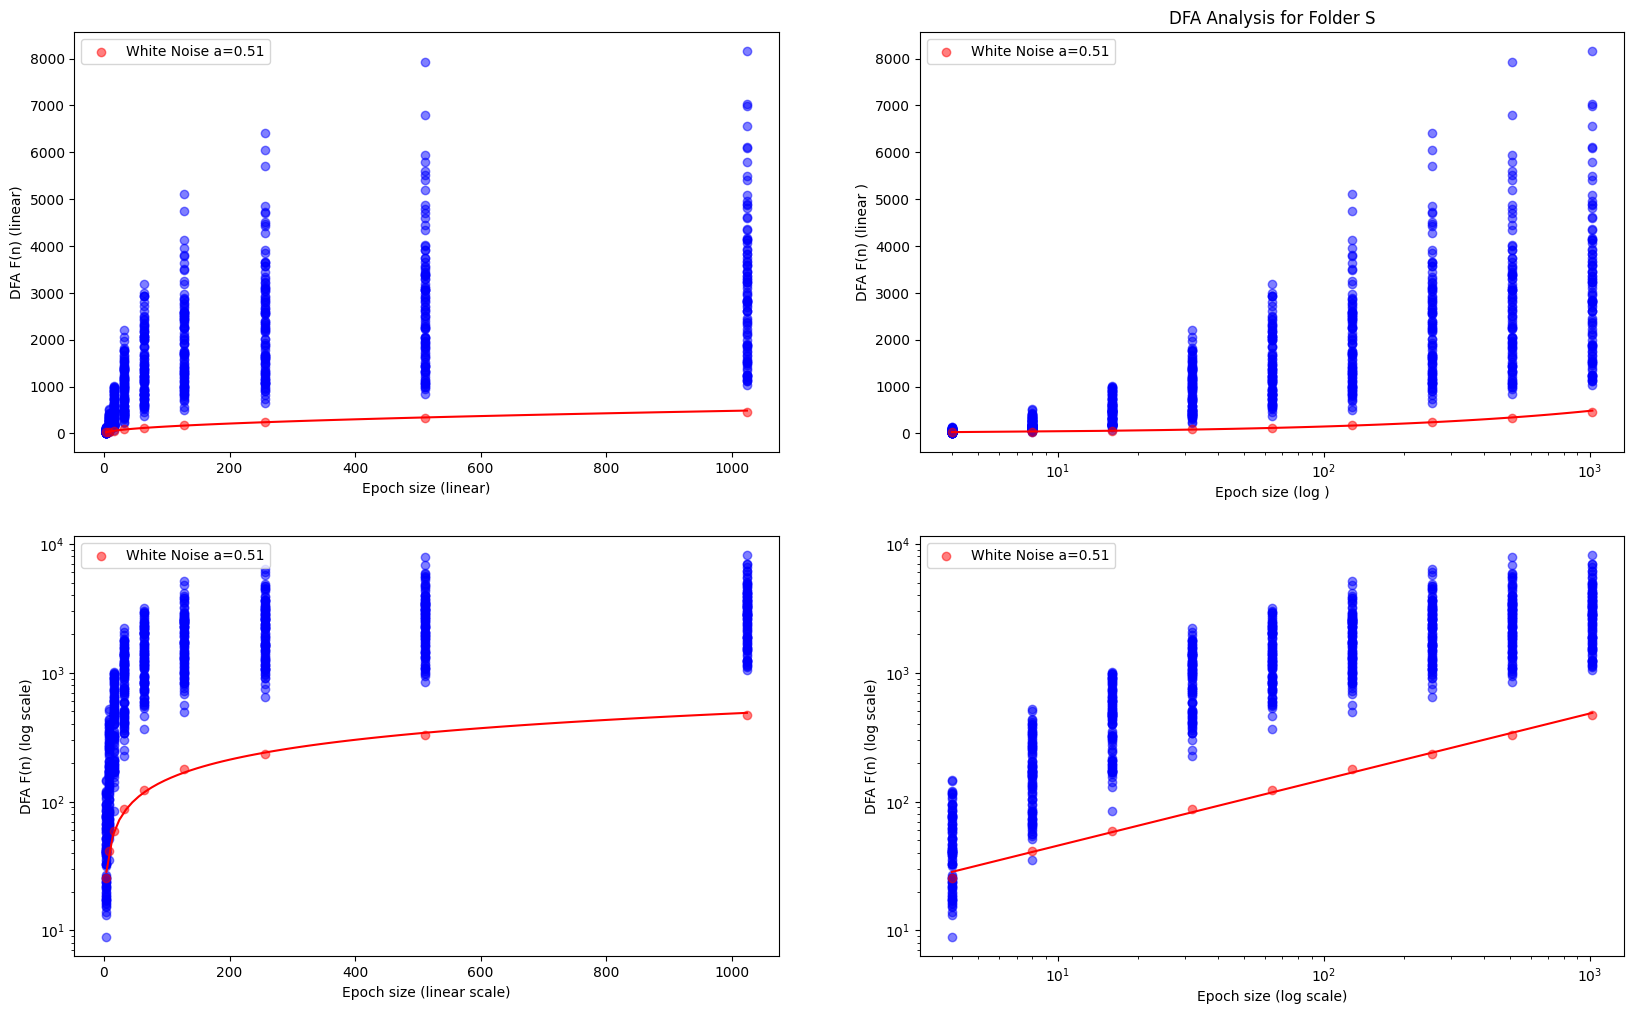

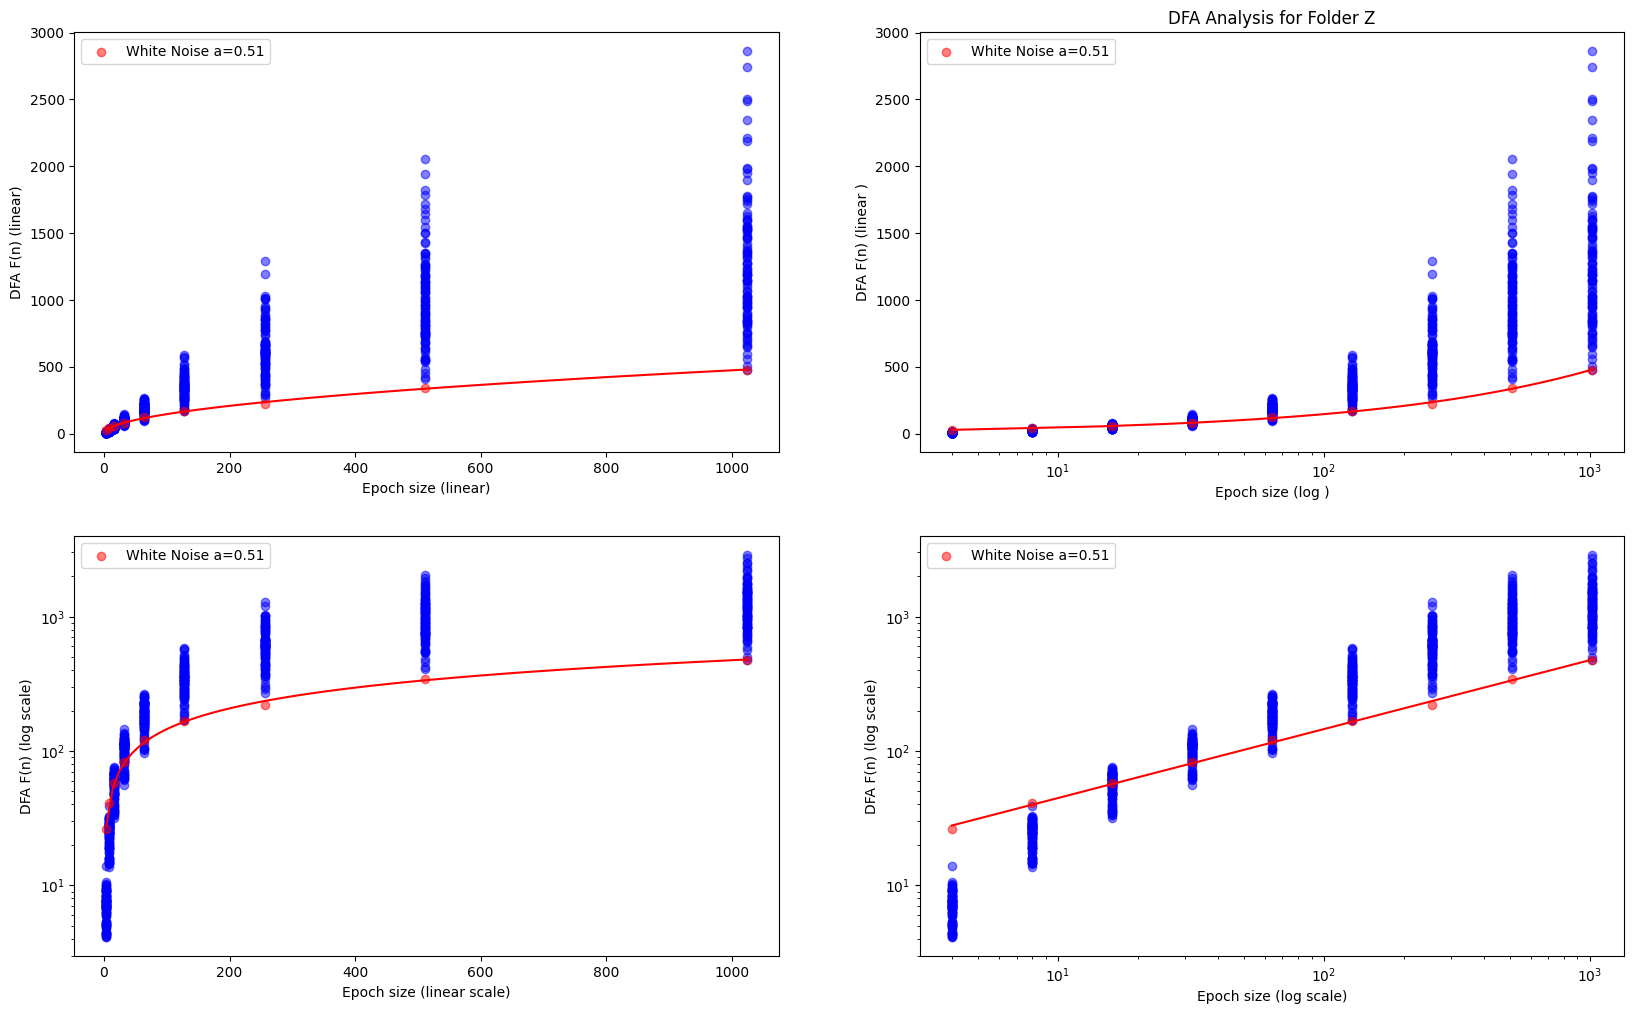

In [ ]:
for folder in range(len(folders)):
    DFA_results = np.load(f'DFA_{filenames[folder]}_results.npy')
    DFA_linfit = np.load(f'DFA_{filenames[folder]}_linfit.npy')
    DFA_Hurst = np.load(f'DFA_{filenames[folder]}_Hurst.npy')
    epochs = epochs

    fig, axs = plt.subplots(2,2,figsize=(20,12))
    axs[0][0].set_xscale('linear')
    axs[0][0].set_yscale('linear')
    axs[0][0].set_xlabel('Epoch size (linear)')
    axs[0][0].set_ylabel(f'DFA F(n) (linear)')

    axs[0][1].set_xscale('log')
    axs[0][1].set_yscale('linear')
    axs[0][1].set_xlabel('Epoch size (log )')
    axs[0][1].set_ylabel('DFA F(n) (linear )')
    axs[0][1].set_title(f'DFA Analysis for Folder {filenames[folder]}')

    axs[1][0].set_xscale('linear')
    axs[1][0].set_yscale('log')
    axs[1][0].set_xlabel('Epoch size (linear scale)')
    axs[1][0].set_ylabel('DFA F(n) (log scale)')

    axs[1][1].set_xscale('log')
    axs[1][1].set_yscale('log')
    axs[1][1].set_xlabel('Epoch size (log scale)')
    axs[1][1].set_ylabel('DFA F(n) (log scale)')

    axs[0][0].scatter(x_extrapolate, np.exp(linear(np.log(x_extrapolate), np.mean(DFA_Hurst), np.mean(DFA_linfit, axis=0)[1])), color='black', label=f'Mean Hurst a={np.mean(DFA_Hurst):.2f}')


    for i in DFA_results:
        axs[0][0].scatter(epochs, i, color='blue', alpha=0.5)
        axs[0][1].scatter(epochs, i, color='blue', alpha=0.5)
        axs[1][0].scatter(epochs, i, color='blue', alpha=0.5)
        axs[1][1].scatter(epochs, i, color='blue', alpha=0.5)


    arr = np.random.uniform(-100, 100, size=(1, 4097))[0]
    processed = prepros(arr)
    DFA_result2 = DFA(processed)
    m2,b2 = fitting(np.log(DFA_result2), np.log(epochs))

    axs[0][0].scatter(epochs, DFA_result2, label=f'White Noise a={m2:.2f}', color='red', alpha=0.5)
    axs[0][0].plot(x_extrapolate, np.exp(linear(np.log(x_extrapolate), m2, b2)), color='red')
    axs[0][0].legend()

    axs[0][1].scatter(epochs, DFA_result2, label=f'White Noise a={m2:.2f}', color='red', alpha=0.5)
    axs[0][1].plot(x_extrapolate, np.exp(linear(np.log(x_extrapolate), m2, b2)), color='red')
    axs[0][1].legend()

    axs[1][0].scatter(epochs, DFA_result2, label=f'White Noise a={m2:.2f}', color='red', alpha=0.5)
    axs[1][0].plot(x_extrapolate, np.exp(linear(np.log(x_extrapolate), m2, b2)), color='red')
    axs[1][0].legend()

    axs[1][1].scatter(epochs, DFA_result2, label=f'White Noise a={m2:.2f}', color='red', alpha=0.5)
    axs[1][1].plot(x_extrapolate, np.exp(linear(np.log(x_extrapolate), m2, b2)), color='red')
    axs[1][1].legend()

    # axs[0][1].scatter(epochs, DFA_result2, label=f'White Noise a={m2:.2f}', color='red', alpha=0.5)
    # axs[0][1].plot(x_extrapolate, np.exp(linear(np.log(x_extrapolate), m2, b2)), color='red')
    # axs[0][1].legend()

    # hist, bin_edges1 = np.histogram(DFA_Hurst, bins='auto', density=True)
    # axs[1].scatter(bin_edges1[:-1], hist)
    # axs[1].set_xlabel('Hurst Exponent')
    # axs[1].set_ylabel('Probability Density (%)')
    # axs[1].set_title(f'Hurst Exponent PDF for Folder {filenames[folder]}')
    plt.savefig(f'{filenames[folder]}_log_matrix.png')
    
